# Clustering Students

**Import libraries**

In [22]:
# for basic mathematics operation 
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

**Costants**

In [4]:
class Columns:
  College_ID = "College_ID"
  IQ = "IQ"
  CGPA = "CGPA"
  Prev_Sem_Result = "Prev_Sem_Result"
  Academic_Performance = "Academic_Performance"
  Internship_Experience = "Internship_Experience"
  Extra_Curricular_Score = "Extra_Curricular_Score"
  Communication_Skills = "Communication_Skills"
  Projects_Completed = "Projects_Completed"
  Placement = "Placement"
  Result_mean = "Result_mean"

**Reaading dataset**

In [5]:
df = pd.read_csv('../data/processed/college_student_placement_clean.csv')
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,0,8,8,4,0
1,CLG0061,97,5.52,5.37,8,0,7,8,0,0
2,CLG0036,109,5.36,5.83,9,0,3,1,1,0
3,CLG0055,122,5.47,5.75,6,1,1,6,1,0
4,CLG0004,96,7.91,7.69,7,0,8,10,2,0


In [6]:
# 1. Inizializzare lo scaler
scaler = StandardScaler()
# df[Columns.Result_mean] = (df[Columns.CGPA] + df[Columns.Prev_Sem_Result]) / 2
# 2. Selezionare le colonne da standardizzare (tutte le colonne numeriche)
columns_to_scale = [Columns.IQ,Columns.CGPA,Columns.Prev_Sem_Result, Columns.Academic_Performance, Columns.Internship_Experience, Columns.Extra_Curricular_Score, Columns.Communication_Skills, Columns.Projects_Completed]
data_to_scale = df[columns_to_scale]

# 3. Calcolare i parametri e trasformare i dati in un solo passaggio
scaled_features = scaler.fit_transform(data_to_scale)

# 4. Riconvertire in un DataFrame e nominare le colonne
df_scaled = pd.DataFrame(scaled_features, columns=columns_to_scale)

# 5. Aggiunta della colonna "Placement"
df_scaled['Placement'] = df['Placement']

print("\nDataFrame Standardizzato (Z-Score):")
df_scaled.head()


DataFrame Standardizzato (Z-Score):


,IQ,CGPA,Prev_Sem_Result,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,0.500135,-0.851919,-0.639521,0.853921,-0.810387,0.958593,0.840550,0.866381,0
1,-0.164214,-1.470939,-1.392572,0.853921,-0.810387,0.642131,0.840550,-1.464794,0
2,0.633004,-1.158028,-1.503111,1.201949,-0.810387,-0.623713,-1.572644,-0.882000,0
3,1.496657,-1.212447,-1.427115,0.157865,1.233979,-1.256636,0.151066,-0.882000,0
4,-0.230648,0.107220,0.258612,0.505893,-0.810387,0.958593,1.530034,-0.299206,0


In [7]:
df_scaled.describe()

,IQ,CGPA,Prev_Sem_Result,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
count,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000
mean,-1.200817e-16,-4.149570e-16,5.726974e-16,-7.602807e-17,1.255884e-16,-9.094947e-17,5.186962e-17,1.033840e-16,0.165900
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,0.372009
min,-3.884563e+00,-2.035539e+00,-1.751825e+00,-1.582274e+00,-8.103865e-01,-1.573097e+00,-1.572644e+00,-1.464794e+00,0.000000
25%,-6.956921e-01,-8.451170e-01,-8.606004e-01,-8.862180e-01,-8.103865e-01,-9.401746e-01,-8.831598e-01,-8.820000e-01,0.000000
50%,-3.134395e-02,1.198652e-02,1.680684e-02,1.578654e-01,-8.103865e-01,9.209021e-03,1.510659e-01,2.835874e-01,0.000000
75%,6.994390e-01,8.418804e-01,8.665792e-01,8.539210e-01,1.233979e+00,9.585926e-01,8.405497e-01,8.663811e-01,0.000000
max,3.888310e+00,1.991488e+00,1.702534e+00,1.549977e+00,1.233979e+00,1.591515e+00,1.530034e+00,1.449175e+00,1.000000


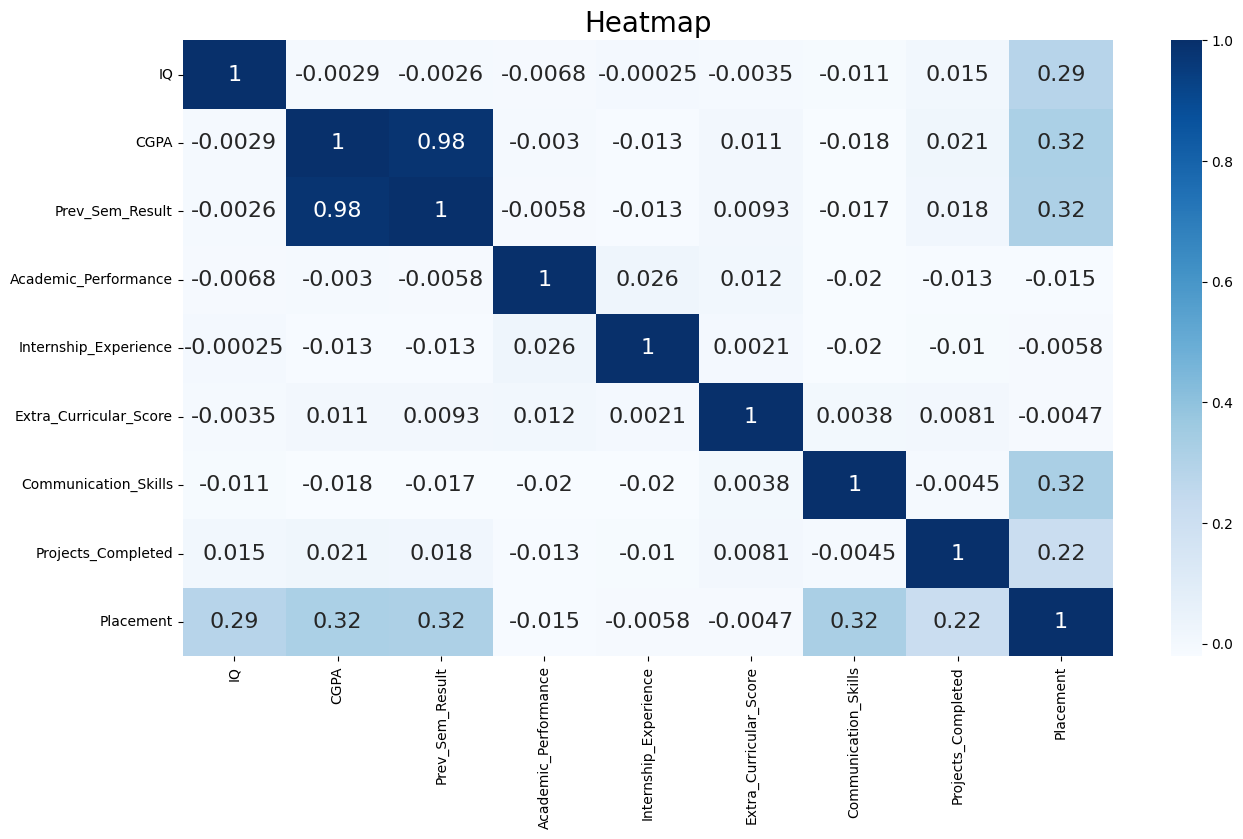

In [76]:
plt.figure(figsize=(15,8))
sns.heatmap(df_scaled.corr(), cmap = 'Blues', annot = True, annot_kws={"fontsize": 16})
plt.title('Heatmap', fontsize = 20)
plt.show()

### Analisi heatmap
1. Forte Multicollinearità (Ridondanza)
L'aspetto più evidente è la correlazione quasi perfetta (0.98) tra CGPA (Media dei voti) e Prev_Sem_Result (Risultato semestre precedente).
Signiche che le due variabili portano quasi la stessa informazione. In molti modelli di machine learning, avere variabili così correlate può creare multicollinearità o semplicemente essere ridondante.
Per il clustering o modelli futuri tenerne solo una (probabilmente CGPA è più rappresentativa) o di combinarle, per evitare di dare troppo "peso" al rendimento scolastico puro rispetto ad altre caratteristiche.

2. Correlazioni con il Target (Placement)
Nell'ultima riga o colonna relativa a Placement si evidenziano quali fattori influenzano di più l'assunzione lineare:
Le correlazioni più alte sono con CGPA (0.32), Prev_Sem_Result (0.32) e Communication_Skills (0.32). Anche il IQ ha un discreto impatto positivo (0.29).
I fattori deboli sono, Internship_Experience e Extra_Curricular_Score che mostrano correlazioni vicine allo zero con il Placement in questo dataset. Questo suggerisce che, almeno linearmente, non sembrano essere fattori determinanti per l'assunzione in questi dati specifici.

3. L'anomalia di Academic_Performance
C'è un dato molto strano: la variabile Academic_Performance ha correlazioni quasi nulle con tutto, persino con CGPA (-0.003).
Normalmente ci si aspetterebbe che la "Performance Accademica" sia legata ai voti (CGPA). Il fatto che sia totalmente scorrelata suggerisce che questa colonna misuri qualcosa di completamente diverso (es. condotta, frequenza) o che i dati in essa contenuti non siano coerenti con le altre metriche di rendimento. Potrebbe essere "rumore" nel dataset.

In [8]:
df_scaled = df_scaled.drop(Columns.Prev_Sem_Result, axis=1)
df_scaled.head()

,IQ,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,0.500135,-0.851919,0.853921,-0.810387,0.958593,0.840550,0.866381,0
1,-0.164214,-1.470939,0.853921,-0.810387,0.642131,0.840550,-1.464794,0
2,0.633004,-1.158028,1.201949,-0.810387,-0.623713,-1.572644,-0.882000,0
3,1.496657,-1.212447,0.157865,1.233979,-1.256636,0.151066,-0.882000,0
4,-0.230648,0.107220,0.505893,-0.810387,0.958593,1.530034,-0.299206,0


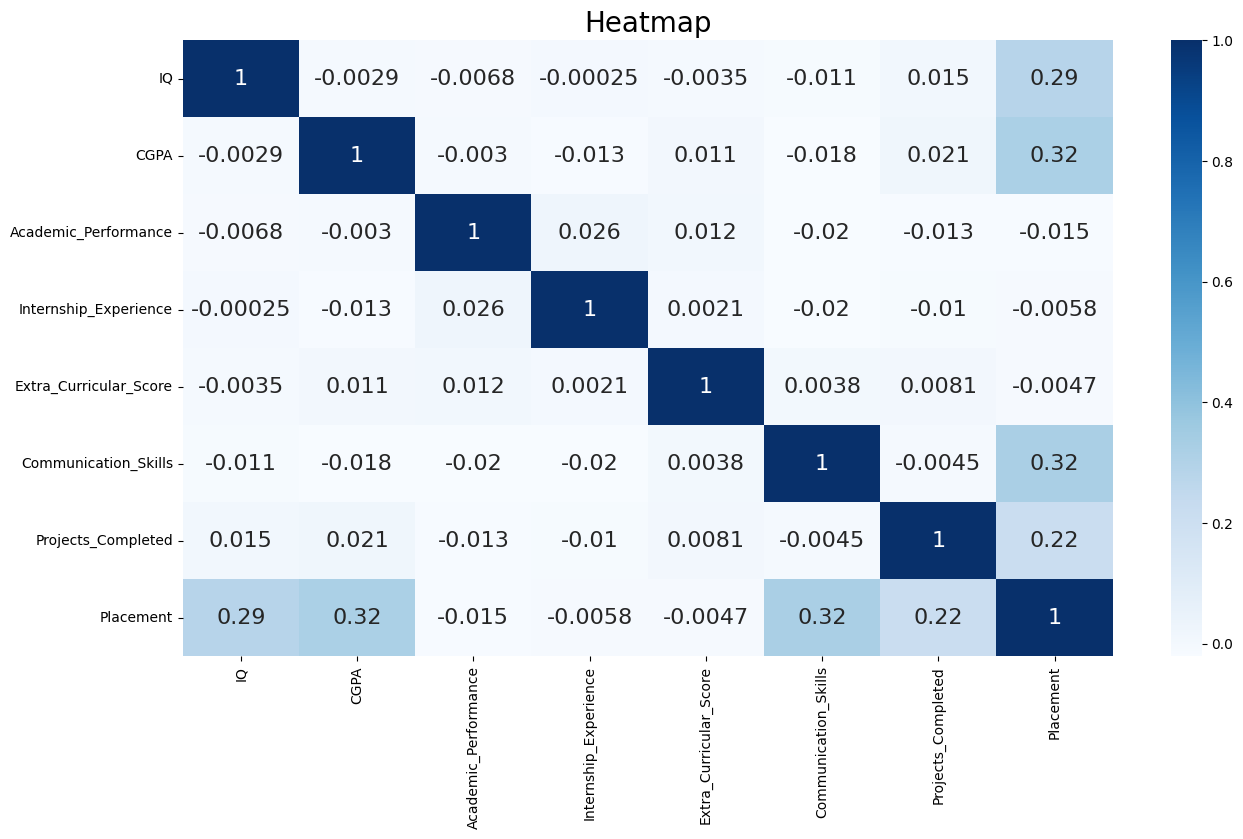

In [9]:
plt.figure(figsize=(15,8))
sns.heatmap(df_scaled.corr(), cmap = 'Blues', annot = True, annot_kws={"fontsize": 16})
plt.title('Heatmap', fontsize = 20)
plt.show()

## Kmeans Algorithm

**Ricerca del numero ottimale di cluster**
L'elbow method ci permette di trovare il numero ottimale di cluster.
WCSS (Within Cluster Sum of Squares) è la somma dei quadrati dei residui all'interno di ogni cluster.

In [26]:
features_to_use = [
    Columns.IQ,
    Columns.CGPA, 
    # Columns.Academic_Performance, # Excluded due to lack of correlation/clarity
    Columns.Internship_Experience,
    Columns.Extra_Curricular_Score,
    Columns.Communication_Skills,
    Columns.Projects_Completed
]
df_high_correlation = df_scaled[features_to_use]

df_high_correlation.head()

,IQ,CGPA,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed
0,0.500135,-0.851919,-0.810387,0.958593,0.840550,0.866381
1,-0.164214,-1.470939,-0.810387,0.642131,0.840550,-1.464794
2,0.633004,-1.158028,-0.810387,-0.623713,-1.572644,-0.882000
3,1.496657,-1.212447,1.233979,-1.256636,0.151066,-0.882000
4,-0.230648,0.107220,-0.810387,0.958593,1.530034,-0.299206


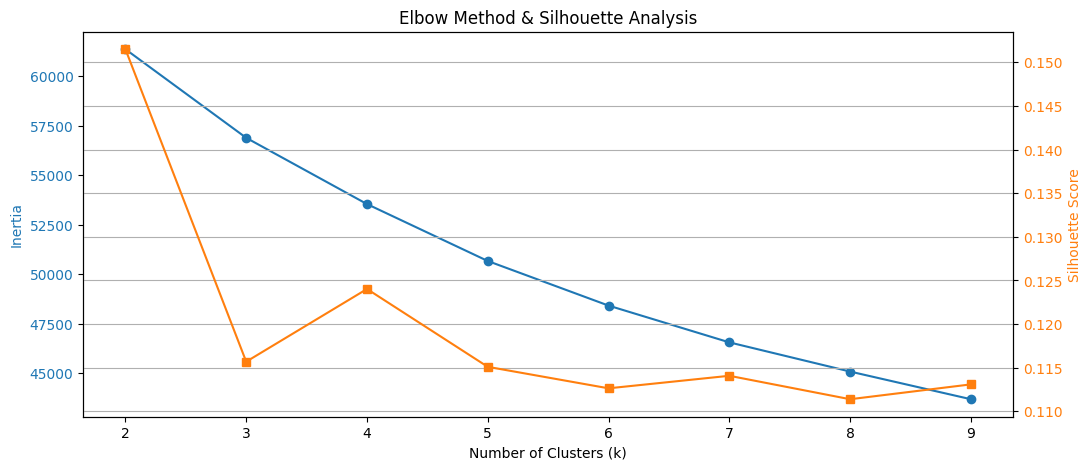

In [27]:
inertia = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

fig, ax1 = plt.subplots(figsize=(12, 5))

# Elbow Curve
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='tab:blue')
ax1.plot(K_range, inertia, color='tab:blue', marker='o', label='Inertia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Silhouette Score
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:orange')
ax2.plot(K_range, silhouette_scores, color='tab:orange', marker='s', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Elbow Method & Silhouette Analysis')
plt.grid(True)
plt.show()

In [17]:
km = KMeans(n_clusters = 2, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
y_means = km.fit_predict(df_high_correlation)
y_means

array([1, 0, 0, ..., 1, 0, 1], shape=(10000,), dtype=int32)

In [18]:
print('df_high_correlation',df_high_correlation.shape)
print('y_means', len(y_means))

df_high_correlation (10000, 4)
y_means 10000


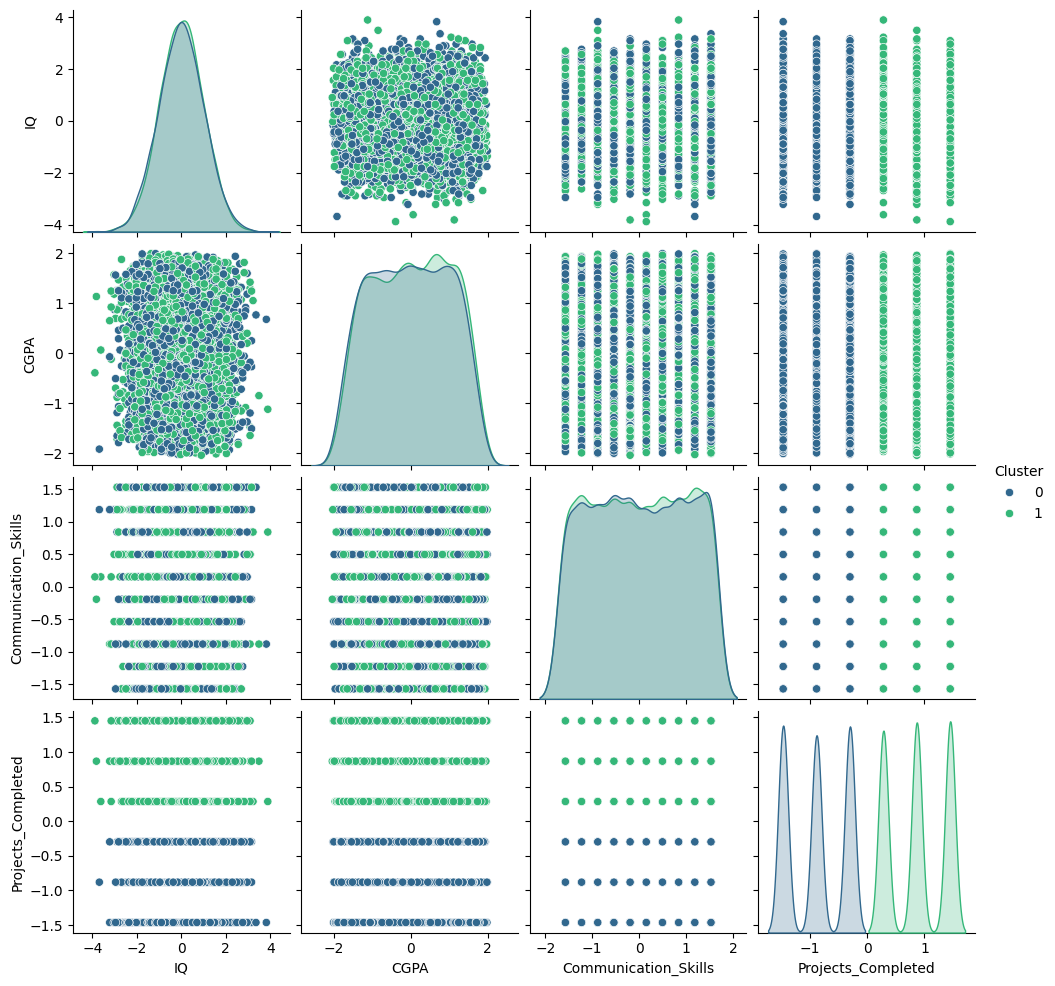

In [19]:
# Aggiungi l'etichetta del cluster al tuo DataFrame originale per poter colorare i punti
df_high_correlation['Cluster'] = y_means

# griglia di grafici
sns.pairplot(df_high_correlation, hue='Cluster', palette='viridis')
plt.show()